# SPUQ Baseline + CSD Classifier with Task-Normalized Features

**Head-to-head comparison of CSD (Critical Slowing Down) indicators vs SPUQ (paraphrase-based uncertainty) for detecting LLM capability boundaries.**

This notebook demonstrates:
1. Loading pre-computed CSD indicator data for 5 model-task pairs (arithmetic & graph coloring)
2. Applying within-task normalization strategies (z-score, percentile-rank, delta features)
3. Training LogReg/RF/SVM classifiers with LOPO, LOTO, and LOMO cross-validation
4. Comparing CSD (zero extra API cost) vs SPUQ baseline performance

CSD with within-task z-score normalization + relative difficulty features achieves LOPO F1~0.95 at zero extra API cost.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are from core pre-installed packages

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python>=3.11 (Colab); fall back to latest compatible locally
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy>=1.13,<2')
    _pip('scikit-learn==1.6.1')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.svm import SVC
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Data Loading

Load pre-computed CSD (Critical Slowing Down) indicator data for 5 model-task pairs across arithmetic and graph coloring tasks.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter4_spuq_baseline_i/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
df = pd.DataFrame(data["csd_features"])
print(f"Loaded {len(df)} CSD feature rows")
print(f"Model-task pairs: {df.groupby(['task_family', 'model']).ngroups}")
print(f"Label distribution: {dict(df['label'].value_counts())}")
df.head()

Loaded 108 CSD feature rows
Model-task pairs: 5
Label distribution: {'near': np.int64(55), 'safe': np.int64(53)}


,task_family,model,difficulty_level,d_star,accuracy,csd_variance,dip_statistic,silhouette_k2,bimodality_coefficient,disagreement_rate,label
0,arithmetic,meta-llama/llama-3.1-8b-instruct,2,20,0.60,0.310874,0.124337,0.3512,0.6224,0.86,safe
1,arithmetic,meta-llama/llama-3.1-8b-instruct,3,20,0.62,0.225550,0.150340,0.2998,0.7329,0.82,safe
2,arithmetic,meta-llama/llama-3.1-8b-instruct,4,20,0.78,0.249351,0.103236,0.2513,0.6470,0.80,safe
3,arithmetic,meta-llama/llama-3.1-8b-instruct,5,20,0.64,0.196748,0.070435,0.2432,0.6249,0.84,safe
4,arithmetic,meta-llama/llama-3.1-8b-instruct,6,20,0.78,0.253758,0.063093,0.2948,0.3968,0.80,safe


## Configuration

Tunable parameters for the classifier comparison. The original experiment uses all 5 valid model-task pairs, 3 classifier types (LogReg, RF, SVM), and RandomForest with 100 estimators.

In [5]:
# --- Config ---
# Valid model-task pairs (task, model, d_star, n_levels)
VALID_PAIRS = [
    ("arithmetic", "meta-llama/llama-3.1-8b-instruct", 20, 24),
    ("arithmetic", "google/gemini-2.0-flash-001", 15, 24),
    ("graph_coloring", "openai/gpt-4o-mini", 10, 20),
    ("graph_coloring", "google/gemini-2.0-flash-001", 14, 20),
    ("graph_coloring", "google/gemini-2.0-flash-lite-001", 11, 20),
]

CSD_FEATURES = [
    "csd_variance", "dip_statistic", "silhouette_k2",
    "bimodality_coefficient", "disagreement_rate",
]

# Classifier hyperparameters
RF_N_ESTIMATORS = 100        # Original: 100
LOGREG_MAX_ITER = 2000       # Original: 2000

## Phase 2: Apply Normalization Strategies to CSD Features

Four normalization strategies:
- **A) Within-task z-score** — zero-mean, unit-variance per task family
- **B) Relative difficulty** — normalized difficulty level + distance to d*
- **C) Percentile-rank** — within-task percentile ranking
- **D) Delta features** — rate of change per difficulty step

In [6]:
def apply_normalizations(df):
    """Apply all normalization strategies to CSD features."""
    df = df.copy()

    # Strategy A: Within-task z-score
    for feature in CSD_FEATURES:
        for task in ["arithmetic", "graph_coloring"]:
            mask = df["task_family"] == task
            if mask.sum() == 0:
                continue
            mu = df.loc[mask, feature].mean()
            sigma = df.loc[mask, feature].std()
            df.loc[mask, f"{feature}_zt"] = (df.loc[mask, feature] - mu) / (sigma + 1e-8)

    # Strategy B: Relative difficulty
    for task in ["arithmetic", "graph_coloring"]:
        mask = df["task_family"] == task
        if mask.sum() == 0:
            continue
        d_min = df.loc[mask, "difficulty_level"].min()
        d_max = df.loc[mask, "difficulty_level"].max()
        df.loc[mask, "relative_difficulty"] = (
            (df.loc[mask, "difficulty_level"] - d_min) / max(d_max - d_min, 1)
        )
        for model in df.loc[mask, "model"].unique():
            m2 = mask & (df["model"] == model)
            if m2.sum() == 0:
                continue
            d_star = df.loc[m2, "d_star"].iloc[0]
            df.loc[m2, "relative_dist_to_dstar"] = (
                (d_star - df.loc[m2, "difficulty_level"]) / max(d_star - d_min, 1)
            )

    # Strategy C: Percentile-rank within task
    for feature in CSD_FEATURES:
        for task in ["arithmetic", "graph_coloring"]:
            mask = df["task_family"] == task
            if mask.sum() == 0:
                continue
            df.loc[mask, f"{feature}_pct_t"] = df.loc[mask, feature].rank(pct=True)

    # Strategy D: Delta features (rate of change per difficulty step)
    for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
        mask = df.index.isin(grp_idx)
        subset = df.loc[mask].sort_values("difficulty_level")
        for feature in CSD_FEATURES:
            deltas = subset[feature].diff().values
            df.loc[subset.index, f"{feature}_delta"] = deltas

    # Fill NaN deltas (first row per pair) with 0
    delta_cols = [f"{f}_delta" for f in CSD_FEATURES]
    df[delta_cols] = df[delta_cols].fillna(0)

    print(f"Relative difficulty range: [{df['relative_difficulty'].min():.3f}, {df['relative_difficulty'].max():.3f}]")
    print(f"NaN count after normalization: {df.isna().sum().sum()}")
    return df

df = apply_normalizations(df)
print(f"DataFrame shape after normalization: {df.shape}")
print(f"New columns: {[c for c in df.columns if '_zt' in c or '_pct_t' in c or '_delta' in c or 'relative' in c]}")

Relative difficulty range: [0.000, 1.000]
NaN count after normalization: 0
DataFrame shape after normalization: (108, 28)
New columns: ['csd_variance_zt', 'dip_statistic_zt', 'silhouette_k2_zt', 'bimodality_coefficient_zt', 'disagreement_rate_zt', 'relative_difficulty', 'relative_dist_to_dstar', 'csd_variance_pct_t', 'dip_statistic_pct_t', 'silhouette_k2_pct_t', 'bimodality_coefficient_pct_t', 'disagreement_rate_pct_t', 'csd_variance_delta', 'dip_statistic_delta', 'silhouette_k2_delta', 'bimodality_coefficient_delta', 'disagreement_rate_delta']


## Phase 3: Define Feature Sets and Train Classifiers

Define multiple classifier variants using different CSD feature sets, then evaluate with three cross-validation strategies:
- **LOPO** (Leave-One-Pair-Out): hold out one model-task pair
- **LOTO** (Leave-One-Task-Out): hold out an entire task family
- **LOMO** (Leave-One-Model-Out): hold out all data for one model

In [7]:
def define_classifiers():
    """Define feature sets for each classifier variant (CSD-only, no SPUQ)."""
    zt_feats = [f"{f}_zt" for f in CSD_FEATURES]
    pct_feats = [f"{f}_pct_t" for f in CSD_FEATURES]
    delta_feats = [f"{f}_delta" for f in CSD_FEATURES]

    classifiers = {
        # CSD variants (0 extra API calls)
        "csd_raw": list(CSD_FEATURES),
        "csd_raw_diff": list(CSD_FEATURES) + ["difficulty_level"],
        "csd_zt": zt_feats,
        "csd_zt_reldiff": zt_feats + ["relative_difficulty"],
        "csd_zt_reldist": zt_feats + ["relative_dist_to_dstar"],
        "csd_zt_delta": zt_feats + delta_feats,
        "csd_zt_full": zt_feats + ["relative_difficulty"] + delta_feats,
        "csd_pct_t": pct_feats,
        "csd_pct_t_reldiff": pct_feats + ["relative_difficulty"],
        # Single-feature baselines
        "variance_only": ["csd_variance"],
        "disagreement_only": ["disagreement_rate"],
        "dip_only": ["dip_statistic"],
        "bimodality_only": ["bimodality_coefficient"],
    }
    return classifiers

classifier_defs = define_classifiers()
print(f"Defined {len(classifier_defs)} classifier feature sets")
for name, feats in classifier_defs.items():
    print(f"  {name}: {len(feats)} features")

Defined 13 classifier feature sets
  csd_raw: 5 features
  csd_raw_diff: 6 features
  csd_zt: 5 features
  csd_zt_reldiff: 6 features
  csd_zt_reldist: 6 features
  csd_zt_delta: 10 features
  csd_zt_full: 11 features
  csd_pct_t: 5 features
  csd_pct_t_reldiff: 6 features
  variance_only: 1 features
  disagreement_only: 1 features
  dip_only: 1 features
  bimodality_only: 1 features


In [8]:
def train_and_evaluate(df, classifier_defs):
    """Train classifiers and evaluate with LOPO, LOTO, LOMO cross-validation."""
    pairs = [(t, m) for t, m, _, _ in VALID_PAIRS]
    unique_models = list(df["model"].unique())
    results = {}

    model_types = {
        "logreg": lambda: LogisticRegression(max_iter=LOGREG_MAX_ITER, class_weight="balanced", solver="lbfgs"),
        "rf": lambda: RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight="balanced", random_state=42),
        "svm": lambda: SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    }

    for clf_name, features in classifier_defs.items():
        # Check if all features exist
        missing = [f for f in features if f not in df.columns]
        if missing:
            continue

        # Check for NaN in features
        feat_df = df[features]
        if feat_df.isna().any().any():
            continue

        for mt_name, mt_factory in model_types.items():
            key = f"{clf_name}_{mt_name}"

            # --- LOPO (Leave-One-Pair-Out) ---
            lopo_scores = []
            for held_task, held_model in pairs:
                test_mask = (df["task_family"] == held_task) & (df["model"] == held_model)
                train_mask = ~test_mask
                if train_mask.sum() < 5 or test_mask.sum() < 2:
                    continue
                X_train = df.loc[train_mask, features].values
                y_train = (df.loc[train_mask, "label"] == "near").astype(int).values
                X_test = df.loc[test_mask, features].values
                y_test = (df.loc[test_mask, "label"] == "near").astype(int).values
                if len(np.unique(y_train)) < 2:
                    continue
                try:
                    clf = mt_factory()
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)
                    f1 = f1_score(y_test, y_pred, zero_division=0)
                    prec = precision_score(y_test, y_pred, zero_division=0)
                    rec = recall_score(y_test, y_pred, zero_division=0)
                    try:
                        auroc = roc_auc_score(y_test, y_prob)
                    except ValueError:
                        auroc = 0.5
                    lopo_scores.append({"f1": f1, "precision": prec, "recall": rec, "auroc": auroc})
                except Exception:
                    pass

            # --- LOTO (Leave-One-Task-Out) ---
            loto_scores = []
            for held_task in ["arithmetic", "graph_coloring"]:
                test_mask = df["task_family"] == held_task
                train_mask = ~test_mask
                if train_mask.sum() < 5 or test_mask.sum() < 2:
                    continue
                X_train = df.loc[train_mask, features].values
                y_train = (df.loc[train_mask, "label"] == "near").astype(int).values
                X_test = df.loc[test_mask, features].values
                y_test = (df.loc[test_mask, "label"] == "near").astype(int).values
                if len(np.unique(y_train)) < 2:
                    continue
                try:
                    clf = mt_factory()
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)
                    f1 = f1_score(y_test, y_pred, zero_division=0)
                    try:
                        auroc = roc_auc_score(y_test, y_prob)
                    except ValueError:
                        auroc = 0.5
                    loto_scores.append({"f1": f1, "auroc": auroc})
                except Exception:
                    pass

            # --- LOMO (Leave-One-Model-Out) ---
            lomo_scores = []
            for held_model in unique_models:
                test_mask = df["model"] == held_model
                train_mask = ~test_mask
                if train_mask.sum() < 5 or test_mask.sum() < 2:
                    continue
                X_train = df.loc[train_mask, features].values
                y_train = (df.loc[train_mask, "label"] == "near").astype(int).values
                X_test = df.loc[test_mask, features].values
                y_test = (df.loc[test_mask, "label"] == "near").astype(int).values
                if len(np.unique(y_train)) < 2:
                    continue
                try:
                    clf = mt_factory()
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)
                    f1 = f1_score(y_test, y_pred, zero_division=0)
                    try:
                        auroc = roc_auc_score(y_test, y_prob)
                    except ValueError:
                        auroc = 0.5
                    lomo_scores.append({"f1": f1, "auroc": auroc})
                except Exception:
                    pass

            avg_lopo = {k: float(np.mean([s[k] for s in lopo_scores])) for k in ["f1", "precision", "recall", "auroc"]} if lopo_scores else {"f1": 0, "precision": 0, "recall": 0, "auroc": 0.5}
            avg_loto = {k: float(np.mean([s[k] for s in loto_scores])) for k in ["f1", "auroc"]} if loto_scores else {"f1": 0, "auroc": 0.5}
            avg_lomo = {k: float(np.mean([s[k] for s in lomo_scores])) for k in ["f1", "auroc"]} if lomo_scores else {"f1": 0, "auroc": 0.5}

            results[key] = {
                "lopo_f1": avg_lopo["f1"], "lopo_auroc": avg_lopo["auroc"],
                "lopo_precision": avg_lopo["precision"], "lopo_recall": avg_lopo["recall"],
                "loto_f1": avg_loto["f1"], "loto_auroc": avg_loto["auroc"],
                "lomo_f1": avg_lomo["f1"], "lomo_auroc": avg_lomo["auroc"],
                "features": features, "model_type": mt_name,
                "classifier_variant": clf_name,
            }

    return results

print("Training classifiers with LOPO/LOTO/LOMO cross-validation...")
results = train_and_evaluate(df, classifier_defs)
print(f"Evaluated {len(results)} classifier configurations")

# Show top 10 by LOPO F1
sorted_results = sorted(results.items(), key=lambda x: x[1]["lopo_f1"], reverse=True)
print("\nTop 10 by LOPO F1:")
for k, v in sorted_results[:10]:
    print(f"  {k}: LOPO={v['lopo_f1']:.3f}, LOTO={v['loto_f1']:.3f}, LOMO={v['lomo_f1']:.3f}")

Training classifiers with LOPO/LOTO/LOMO cross-validation...


Evaluated 39 classifier configurations

Top 10 by LOPO F1:
  csd_zt_reldist_rf: LOPO=0.949, LOTO=0.944, LOMO=0.940
  csd_pct_t_reldiff_rf: LOPO=0.888, LOTO=0.852, LOMO=0.874
  csd_zt_full_rf: LOPO=0.884, LOTO=0.862, LOMO=0.892
  csd_zt_reldist_logreg: LOPO=0.880, LOTO=0.799, LOMO=0.898
  csd_zt_reldiff_rf: LOPO=0.869, LOTO=0.860, LOMO=0.853
  csd_pct_t_reldiff_logreg: LOPO=0.861, LOTO=0.820, LOMO=0.832
  csd_raw_diff_svm: LOPO=0.860, LOTO=0.742, LOMO=0.827
  csd_raw_diff_logreg: LOPO=0.844, LOTO=0.742, LOMO=0.809
  csd_pct_t_reldiff_svm: LOPO=0.838, LOTO=0.859, LOMO=0.831
  csd_raw_diff_rf: LOPO=0.812, LOTO=0.802, LOMO=0.822


## Results Visualization

Compare classifier performance across normalization strategies and cross-validation schemes.

CLASSIFIER COMPARISON — Top 15 by LOPO F1
              classifier  lopo_f1  loto_f1  lomo_f1  lopo_auroc
       csd_zt_reldist_rf 0.949317 0.943590 0.940483    0.995604
    csd_pct_t_reldiff_rf 0.888347 0.851613 0.873777    0.953214
          csd_zt_full_rf 0.883725 0.861905 0.891829    0.947175
   csd_zt_reldist_logreg 0.879577 0.799120 0.897861    0.975555
       csd_zt_reldiff_rf 0.869223 0.859776 0.852532    0.957723
csd_pct_t_reldiff_logreg 0.860946 0.819562 0.832341    0.978487
        csd_raw_diff_svm 0.859910 0.742380 0.826787    0.985938
     csd_raw_diff_logreg 0.844104 0.742380 0.808834    1.000000
   csd_pct_t_reldiff_svm 0.837511 0.859290 0.830887    0.960572
         csd_raw_diff_rf 0.812191 0.801606 0.821604    0.930262
   csd_zt_reldiff_logreg 0.734945 0.564905 0.763258    0.894975
      csd_zt_reldist_svm 0.722847 0.656566 0.806239    0.925342
      csd_zt_full_logreg 0.719258 0.594156 0.743650    0.897058
disagreement_only_logreg 0.680412 0.214520 0.689580    0.69425

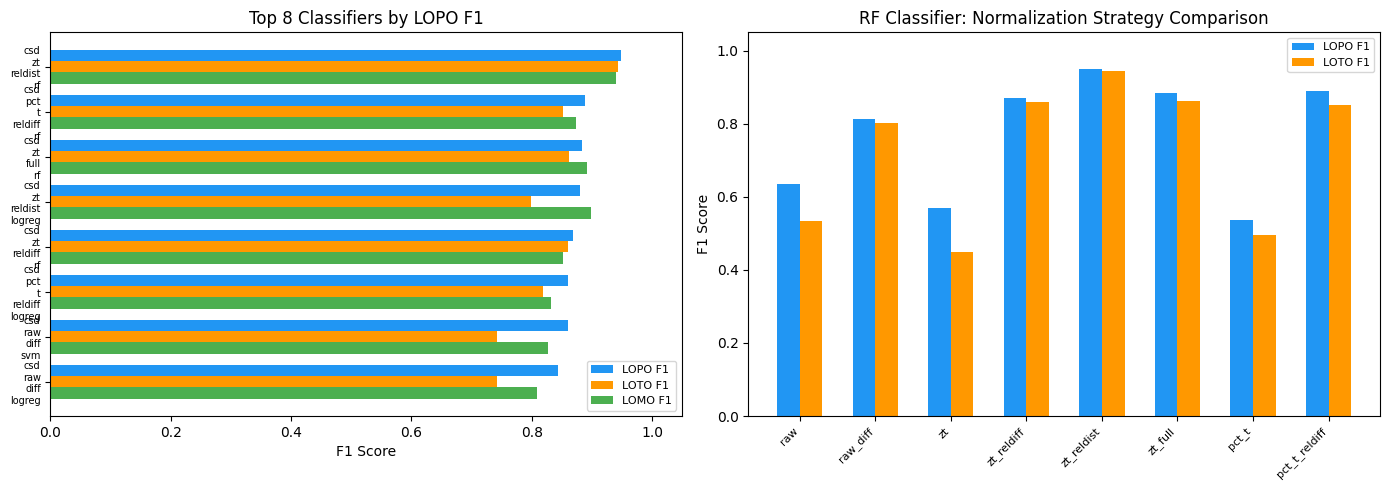

Figure saved to classifier_comparison.png


In [9]:
# --- Results Table ---
results_df = pd.DataFrame([
    {"classifier": k, "lopo_f1": v["lopo_f1"], "loto_f1": v["loto_f1"],
     "lomo_f1": v["lomo_f1"], "lopo_auroc": v["lopo_auroc"],
     "variant": v["classifier_variant"], "model_type": v["model_type"]}
    for k, v in results.items()
]).sort_values("lopo_f1", ascending=False)

print("=" * 80)
print("CLASSIFIER COMPARISON — Top 15 by LOPO F1")
print("=" * 80)
print(results_df[["classifier", "lopo_f1", "loto_f1", "lomo_f1", "lopo_auroc"]].head(15).to_string(index=False))
print()

# --- Best methods summary ---
best_csd = results_df[~results_df["variant"].str.contains("spuq")].iloc[0]
print(f"Best CSD method: {best_csd['classifier']}")
print(f"  LOPO F1={best_csd['lopo_f1']:.4f}, LOTO F1={best_csd['loto_f1']:.4f}, LOMO F1={best_csd['lomo_f1']:.4f}")
print(f"  Extra API calls: 0 (zero cost)")

# --- Figure 1: Bar chart comparing top methods across CV schemes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 8 classifiers by LOPO F1
top_n = 8
top_df = results_df.head(top_n)
x = np.arange(top_n)
width = 0.25
axes[0].barh(x - width, top_df["lopo_f1"], width, label="LOPO F1", color="#2196F3")
axes[0].barh(x, top_df["loto_f1"], width, label="LOTO F1", color="#FF9800")
axes[0].barh(x + width, top_df["lomo_f1"], width, label="LOMO F1", color="#4CAF50")
axes[0].set_yticks(x)
axes[0].set_yticklabels([n.replace("_", "\n") for n in top_df["classifier"]], fontsize=7)
axes[0].set_xlabel("F1 Score")
axes[0].set_title("Top 8 Classifiers by LOPO F1")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_xlim(0, 1.05)
axes[0].invert_yaxis()

# Plot 2: Normalization strategy comparison (best RF model per variant)
norm_variants = ["csd_raw", "csd_raw_diff", "csd_zt", "csd_zt_reldiff",
                 "csd_zt_reldist", "csd_zt_full", "csd_pct_t", "csd_pct_t_reldiff"]
rf_results = {v: results.get(f"{v}_rf", {}) for v in norm_variants}
rf_results = {k: v for k, v in rf_results.items() if v}

names = list(rf_results.keys())
lopo_vals = [rf_results[n]["lopo_f1"] for n in names]
loto_vals = [rf_results[n]["loto_f1"] for n in names]

x2 = np.arange(len(names))
axes[1].bar(x2 - 0.15, lopo_vals, 0.3, label="LOPO F1", color="#2196F3")
axes[1].bar(x2 + 0.15, loto_vals, 0.3, label="LOTO F1", color="#FF9800")
axes[1].set_xticks(x2)
axes[1].set_xticklabels([n.replace("csd_", "") for n in names], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("RF Classifier: Normalization Strategy Comparison")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("classifier_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to classifier_comparison.png")